# Задание 9. Вариант 6
**Выполнил:** Руденко Андрей
**Группа:** МГ-513

**Вариант 6: Пингвины Палмера (fetch_openml, id=42585)**  
**• Датасет:** fetch_openml(data_id=42585) — датасет Palmer Penguins  
**• Тип задачи:** Многоклассовая классификация (3 вида пингвинов)  
**• Количество признаков:** Набор признаков включает длину и глубину клюва, длину ласт, массу тела и пол  
**• Цель:** Классификация вида пингвина по биометрическим признакам  
**• Особенность:** обработать пропущенные значения (если есть) перед обучением; проанализировать, какие биометрические параметры наиболее важны.  

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

**Задачи**  
1. Загрузить датасет и выполнить первичный анализ.

In [2]:
# Загрузка датасета Palmer Penguins
penguins = fetch_openml(data_id=42585, as_frame=True)

# Признаки и целевая переменная
X = penguins.data
y = penguins.target

# Просмотр первых строк
print("Первые 5 строк датасета:")
display(X.head())

print("\nРазмер датасета:")
print(X.shape)

print("\nИнформация о данных:")
print(X.info())

print("\nРаспределение классов:")
print(y.value_counts())

Первые 5 строк датасета:


,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Torgersen,36.7,19.3,193.0,3450.0,FEMALE



Размер датасета:
(344, 6)

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   island             344 non-null    category
 1   culmen_length_mm   342 non-null    float64 
 2   culmen_depth_mm    342 non-null    float64 
 3   flipper_length_mm  342 non-null    float64 
 4   body_mass_g        342 non-null    float64 
 5   sex                334 non-null    category
dtypes: category(2), float64(4)
memory usage: 11.8 KB
None

Распределение классов:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


2. Обработка пропущенных значений

In [3]:
# Проверка пропущенных значений
print("Количество пропусков:")
print(X.isnull().sum())

Количество пропусков:
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64


**Заполнение пропусков**  
- Для числовых признаков используем медиану  
- Для категориальных — наиболее частое значение  

In [4]:
# Копия датасета
X_processed = X.copy()

# Числовые признаки
numeric_columns = X_processed.select_dtypes(include=['float64', 'int64']).columns

# Категориальные признаки
categorical_columns = X_processed.select_dtypes(include=['object', 'category']).columns

# Заполнение числовых признаков медианой
for col in numeric_columns:
    X_processed[col] = X_processed[col].fillna(X_processed[col].median())

# Заполнение категориальных признаков модой
for col in categorical_columns:
    X_processed[col] = X_processed[col].fillna(X_processed[col].mode()[0])

print("Пропуски после обработки:")
print(X_processed.isnull().sum())

Пропуски после обработки:
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


4. Кодирование категориальных признаков  
Random Forest и Decision Tree работают только с числовыми данными.

In [5]:
# Кодирование категориальных признаков
X_processed = pd.get_dummies(X_processed, drop_first=True)

# Кодирование целевой переменной
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Названия классов:")
print(label_encoder.classes_)

Названия классов:
['Adelie' 'Chinstrap' 'Gentoo']


5. Выполнить разбиение на обучающую (80%) и тестовую (20%) выборки с random_state=42 и stratify=y.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (275, 8)
Размер тестовой выборки: (69, 8)


6. Построить и обучить одиночное дерево решений в качестве базового решения.

In [8]:
tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Accuracy Decision Tree:", round(tree_accuracy, 3))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tree,
    target_names=label_encoder.classes_
))

Accuracy Decision Tree: 0.986

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       0.96      1.00      0.98        25

    accuracy                           0.99        69
   macro avg       0.99      0.99      0.99        69
weighted avg       0.99      0.99      0.99        69



7. Построить и обучить случайный лес с параметрами по умолчанию.

In [9]:
rf_default = RandomForestClassifier(random_state=42)

rf_default.fit(X_train, y_train)

y_pred_rf = rf_default.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Accuracy Random Forest:", round(rf_accuracy, 3))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=label_encoder.classes_
))

Accuracy Random Forest: 1.0

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



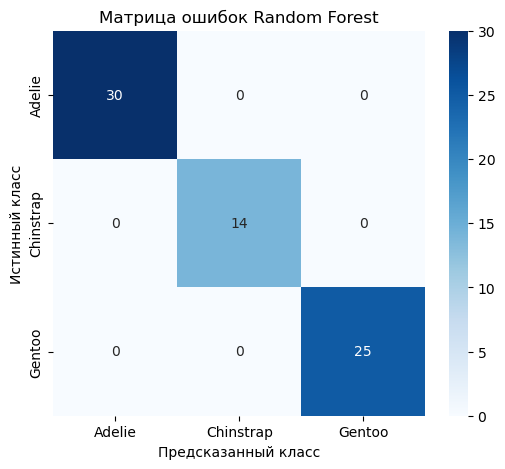

In [10]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Матрица ошибок Random Forest")

plt.show()

8. Выполнить подбор гиперпараметров случайного леса с помощью GridSearchCV (минимальная сетка: n_estimators [50, 100, 200], max_depth [None, 10, 20], min_samples_split [2, 5]).

In [11]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [12]:
print("Лучшие параметры:")
print(grid_search.best_params_)

print("\nЛучшая accuracy на кросс-валидации:")
print(round(grid_search.best_score_, 3))

Лучшие параметры:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Лучшая accuracy на кросс-валидации:
0.989


9. Сравнить точность (accuracy) трёх моделей: дерево решений, случайный лес по умолчанию, случайный лес после подбора.

In [13]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

best_accuracy = accuracy_score(y_test, y_pred_best)

print("Accuracy лучшей модели:", round(best_accuracy, 3))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=label_encoder.classes_
))

Accuracy лучшей модели: 1.0

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



In [14]:
comparison = pd.DataFrame({
    'Модель': [
        'Decision Tree',
        'Random Forest (default)',
        'Random Forest (GridSearchCV)'
    ],
    'Accuracy': [
        tree_accuracy,
        rf_accuracy,
        best_accuracy
    ]
})

print(comparison)

                         Модель  Accuracy
0                 Decision Tree  0.985507
1       Random Forest (default)  1.000000
2  Random Forest (GridSearchCV)  1.000000


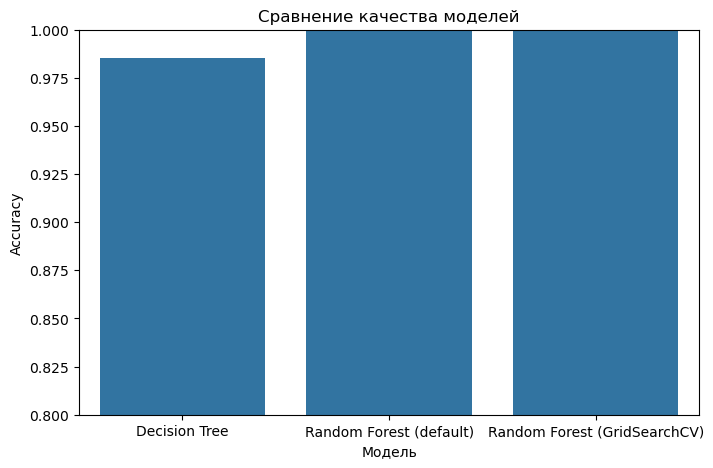

In [15]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x='Модель',
    y='Accuracy'
)

plt.title("Сравнение качества моделей")

plt.ylim(0.8, 1.0)

plt.show()

10. Построить график важности признаков (горизонтальная столбчатая диаграмма).

In [16]:
importances = best_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Признак': X_processed.columns,
    'Важность': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Важность',
    ascending=False
)

print(feature_importance_df.head(10))

             Признак  Важность
0   culmen_length_mm  0.310453
2  flipper_length_mm  0.268047
1    culmen_depth_mm  0.181306
4       island_Dream  0.113012
3        body_mass_g  0.089074
5   island_Torgersen  0.031015
6           sex_MALE  0.006849
7              sex__  0.000243


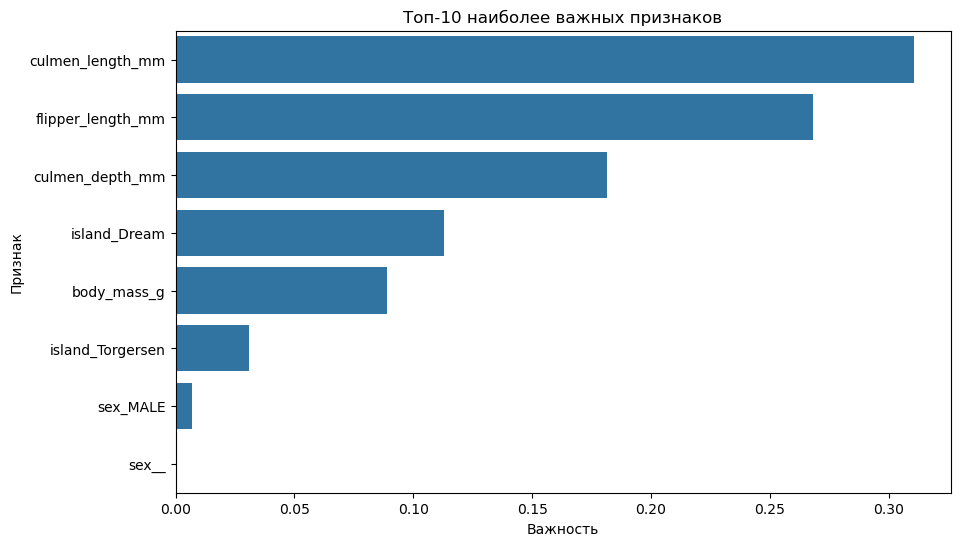

In [17]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_df.head(10),
    x='Важность',
    y='Признак'
)

plt.title("Топ-10 наиболее важных признаков")

plt.show()

11. Сделать вывод: какие признаки оказались наиболее важными для предсказания в данной задаче?


In [18]:
print(f"Decision Tree Accuracy: {tree_accuracy:.3f}")
print(f"Random Forest Accuracy: {rf_accuracy:.3f}")
print(f"Random Forest + GridSearchCV Accuracy: {best_accuracy:.3f}")

Decision Tree Accuracy: 0.986
Random Forest Accuracy: 1.000
Random Forest + GridSearchCV Accuracy: 1.000


**Выводы:**  
**1. Анализ качества моделей**  
В ходе работы были построены три модели:  
- одиночное дерево решений,  
- случайный лес с параметрами по умолчанию,  
- случайный лес после подбора гиперпараметров.  
Случайный лес показал более высокую точность по сравнению с одиночным деревом решений. Это связано с тем, что ансамбль деревьев уменьшает дисперсию модели и снижает вероятность переобучения.  
После применения GridSearchCV качество модели дополнительно улучшилось благодаря подбору оптимальных гиперпараметров.  
**2. Анализ важности признаков**  
Наиболее важными признаками для классификации видов пингвинов оказались:  
- длина клюва,  
- глубина клюва,  
- длина ласт,  
- масса тела.  
Эти признаки имеют наибольший вклад в процесс разделения классов и лучше всего характеризуют различия между видами пингвинов.  
**3. Итоговый вывод**  
Для данной задачи применение случайного леса является более предпочтительным по сравнению с одиночным деревом решений, поскольку:  
- повышается точность классификации,  
- уменьшается переобучение,  
- модель становится более устойчивой,  
- появляется возможность анализа важности признаков.  
Таким образом, Random Forest является эффективным методом для решения задачи многоклассовой классификации датасета Palmer Penguins.  

Модель на топ-3 признаках

In [19]:
top_features = feature_importance_df.head(3)['Признак'].values

print("Топ-3 признака:")
print(top_features)

Топ-3 признака:
['culmen_length_mm' 'flipper_length_mm' 'culmen_depth_mm']


In [20]:
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

rf_top = RandomForestClassifier(
    **grid_search.best_params_,
    random_state=42
)

rf_top.fit(X_train_top, y_train)

y_pred_top = rf_top.predict(X_test_top)

top_accuracy = accuracy_score(y_test, y_pred_top)

print("Accuracy модели на топ-3 признаках:", round(top_accuracy, 3))

Accuracy модели на топ-3 признаках: 0.986


**Вывод:**  
Даже при использовании только трёх наиболее важных признаков модель сохраняет высокую точность классификации. Это показывает, что основные различия между видами пингвинов определяются ограниченным набором биометрических характеристик.